# Variational Classifier

resource: https://pennylane.ai/qml/demos/tutorial_variational_classifier

1. Parity function
2. Encoding
3. Encode real vectors to quantum state


In [1]:
import pennylane as qp
from pennylane import numpy as np
from pennylane.optimize import NesterovMomentumOptimizer

In [2]:
# define a device
dev = qp.device("default.qubit")

## Variational classifiers architecture

In [3]:
def layer(layer_weights):
    for wire in range(4):
        qp.Rot(*layer_weights[wire], wires=wire)

    for wires in ([0, 1], [1, 2], [2, 3], [3, 0]):
        qp.CNOT(wires)

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mi>x</mi>
  <mo>=</mo>
  <mn>0101</mn>
  <mo stretchy="false">&#x2192;</mo>
  <mrow data-mjx-texclass="ORD">
    <mo stretchy="false">|</mo>
  </mrow>
  <mi>&#x3C8;</mi>
  <mo fence="false" stretchy="false">&#x27E9;</mo>
  <mo>=</mo>
  <mrow data-mjx-texclass="ORD">
    <mo stretchy="false">|</mo>
  </mrow>
  <mn>0101</mn>
  <mo fence="false" stretchy="false">&#x27E9;</mo>
  <mo>.</mo>
</math>

Next, encode data inputs x into quantum vector or quantum states

In [4]:
def state_preparation(x):
    qp.BasisState(x, wires=[0, 1, 2, 3])

### Variational Quantum Circuit

In [5]:
@qp.qnode(dev)
def circuit(weights, x):
    state_preparation(x)

    for layer_weights in weights:
        layer(layer_weights)

    return qp.expval(qp.PauliZ(0))

#### Visualization

(<Figure size 1400x500 with 1 Axes>, <Axes: >)

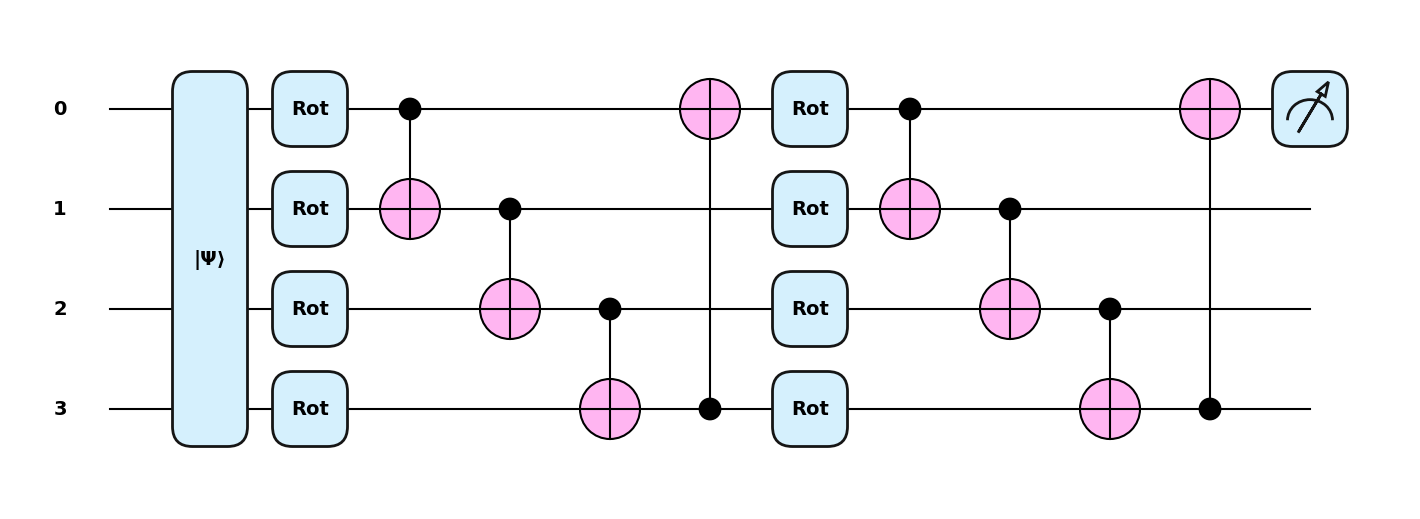

In [6]:
n_layers = 2
qp.drawer.use_style('pennylane')
qp.draw_mpl(circuit)(np.random.randn(n_layers, 4, 3, requires_grad=True), np.array([0, 0, 0, 1]))

#### Classifier

In [7]:
# Classifier
def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias

In [8]:
# Loss function
def square_loss(labels, predictions):
    return np.mean((labels - qp.math.stack(predictions)) ** 2)


In [9]:
# Evaluation
def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

In [10]:
# Cost function
def cost(weights, bias, X, Y):
    predictions = [variational_classifier(weights, bias, x) for x in X]
    return square_loss(Y, predictions)

In [11]:
data = np.loadtxt("variational_classifier/parity_train.txt", dtype=int)
X = np.array(data[:, :-1])
Y = np.array(data[:, -1])
Y = Y * 2 - 1

for x, y in zip(X, Y):
    print(f"x = {x}, y = {y}")


x = [0 0 0 1], y = 1
x = [0 0 1 0], y = 1
x = [0 1 0 0], y = 1
x = [0 1 0 1], y = -1
x = [0 1 1 0], y = -1
x = [0 1 1 1], y = 1
x = [1 0 0 0], y = 1
x = [1 0 0 1], y = -1
x = [1 0 1 1], y = 1
x = [1 1 1 1], y = -1


In [12]:
np.random.seed(0)
num_qubits = 4
num_layers = 2
weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3, requires_grad=True)
bias_init = np.array(0.0, requires_grad=True)

print("Weights:", weights_init)
print("Bias:", bias_init)

Weights: [[[ 0.01764052  0.00400157  0.00978738]
  [ 0.02240893  0.01867558 -0.00977278]
  [ 0.00950088 -0.00151357 -0.00103219]
  [ 0.00410599  0.00144044  0.01454274]]

 [[ 0.00761038  0.00121675  0.00443863]
  [ 0.00333674  0.01494079 -0.00205158]
  [ 0.00313068 -0.00854096 -0.0255299 ]
  [ 0.00653619  0.00864436 -0.00742165]]]
Bias: 0.0


In [13]:
opt = NesterovMomentumOptimizer(0.5)
batch_size = 5

In [14]:
weights = weights_init
bias = bias_init

for it in range(100):

    batch_index = np.random.randint(0, len(X), (batch_size,))
    X_batch = X[batch_index]
    Y_batch = Y[batch_index]
    weights, bias = opt.step(cost, weights, bias, X=X_batch, Y=Y_batch)
    
    predictions = [np.sign(variational_classifier(weights, bias, x)) for x in X]

    current_cost = cost(weights, bias, X, Y)
    acc = accuracy(Y, predictions)

    print(f"Iter: {it+1:4d} | Cost: {current_cost:0.7f} | Accuracy: {acc:0.7f}")

Iter:    1 | Cost: 2.3147651 | Accuracy: 0.5000000
Iter:    2 | Cost: 1.9664866 | Accuracy: 0.5000000
Iter:    3 | Cost: 1.9208589 | Accuracy: 0.5000000
Iter:    4 | Cost: 2.6276126 | Accuracy: 0.5000000
Iter:    5 | Cost: 0.9323119 | Accuracy: 0.6000000
Iter:    6 | Cost: 1.1903549 | Accuracy: 0.5000000
Iter:    7 | Cost: 2.0508989 | Accuracy: 0.4000000
Iter:    8 | Cost: 1.1275531 | Accuracy: 0.6000000
Iter:    9 | Cost: 1.1659803 | Accuracy: 0.6000000
Iter:   10 | Cost: 1.1349618 | Accuracy: 0.6000000
Iter:   11 | Cost: 0.9994063 | Accuracy: 0.6000000
Iter:   12 | Cost: 1.0812559 | Accuracy: 0.6000000
Iter:   13 | Cost: 1.2863155 | Accuracy: 0.6000000
Iter:   14 | Cost: 2.2658259 | Accuracy: 0.4000000
Iter:   15 | Cost: 1.1323724 | Accuracy: 0.6000000
Iter:   16 | Cost: 1.3439737 | Accuracy: 0.8000000
Iter:   17 | Cost: 2.0076168 | Accuracy: 0.6000000
Iter:   18 | Cost: 1.2685760 | Accuracy: 0.5000000
Iter:   19 | Cost: 1.6762475 | Accuracy: 0.5000000
Iter:   20 | Cost: 1.1868237 | 